📌 Introduction

In the age of digital streaming platforms and overwhelming content availability, users often struggle to decide what to watch next. To tackle this challenge, recommender systems have emerged as powerful tools that personalize content suggestions based on user preferences and behavior patterns.

This project aims to build a recommender system that provides personalized movie recommendations using a combination of techniques rooted in collaborative filtering. The system analyzes user ratings and identifies patterns in preferences by comparing them with other users who exhibit similar tastes.

We leverage the MovieLens 1M Dataset, which contains over 1 million ratings from 6,000 users on nearly 4,000 movies, along with demographic details such as age, gender, and occupation.

🎯 Objective

To design and implement a personalized movie recommendation system that:

Predicts movies a user is likely to enjoy based on past ratings.

Identifies similar users or items using similarity measures.

Uses collaborative filtering and matrix factorization for deeper insight into user-item relationships.

Enhances user experience by reducing decision fatigue.

🧠 Approach & Techniques

We explore multiple collaborative filtering techniques and model-based approaches to create robust recommendations:

✅ Collaborative Filtering Approaches

Item-Based Filtering using:

Pearson Correlation

Cosine Similarity (with K-Nearest Neighbors)

User-Based Filtering (optional extension)

✅ Model-Based Approaches

Matrix Factorization using the Surprise library

Evaluated using RMSE (Root Mean Squared Error) and MAPE (Mean Absolute Percentage Error)

Embedding visualization to understand latent features

🔍 Steps Followed

Data Loading & Merging

Read .dat files and format them into structured dataframes.

Merge ratings, users, and movies data into a single unified dataframe.

Data Cleaning & Feature Engineering

Convert data types and extract features like Release Year from movie titles.

Create visualizations to understand user demographics, genre preferences, and rating patterns.

Exploratory Data Analysis (EDA)

Analyze distribution of ratings, popular movies, most active users.

Identify top-rated genres and understand rating trends by age, gender, and occupation.

Building the Recommender System

Create a pivot table of users vs. movies and impute missing values.

Compute item-item similarity using Pearson and Cosine metrics.

Recommend top 5 similar movies to a given movie.

Model-Based Recommendation (Matrix Factorization)

Use the Surprise SVD algorithm to predict unknown ratings.

Evaluate model accuracy using RMSE and MAPE.

Visualize item and user embeddings using dimensionality reduction techniques.

(Optional) User-Based Recommendation

Take a few user ratings, find users with similar rating profiles.

Calculate weighted scores to recommend movies based on similar users' preferences.

📊 Key Concepts Applied

Collaborative Filtering (Item & User-based)

Pearson Correlation Coefficient

Cosine Similarity & K-Nearest Neighbors

Matrix Factorization (SVD)

CSR (Compressed Sparse Row) Matrix Representation

Evaluation Metrics: RMSE, MAPE

Data Visualization: Ratings distribution, user demographics, genre heatmaps

✅ Expected Outcomes

By the end of this project, we will:

Recommend top movies to users based on their past preferences.

Identify similar users and items using collaborative techniques.

Evaluate the accuracy and performance of different recommender models.

Visualize hidden relationships between users and movies through embeddings.

📚 Data Dictionary

The dataset consists of three main files, each providing important information used to build the recommender system.

1. Ratings File (ratings.dat)
Field	Description
UserID	Unique identifier for each user (1 to 6040)
MovieID	Unique identifier for each movie (1 to 3952)
Rating	User’s rating for a movie on a 1 to 5 scale
Timestamp	Time when the rating was recorded (in seconds)

Each user has rated at least 20 movies.

Ratings are whole-star values (no decimals).

2. Users File (users.dat)
Field	Description
UserID	Unique identifier for each user
Gender	User’s gender: M for Male, F for Female
Age	User’s age group code:
	1 = Under 18, 18 = 18-24, 25 = 25-34, 35 = 35-44, etc.
Occupation	User’s profession (encoded as integers 0–20), e.g.,
	0 = other, 1 = academic/educator, 12 = programmer, etc.
Zip-code	User’s postal code

Demographic info is self-reported and may not be fully accurate.

Only users who provided demographic data are included.

3. Movies File (movies.dat)
Field	Description
MovieID	Unique identifier for each movie
Title	Movie title with release year (e.g., Toy Story (1995))
Genres	Pipe-separated list of genres (e.g., `Comedy

Genres include: Action, Adventure, Comedy, Drama, Sci-Fi, Thriller, etc.

Titles are consistent with IMDB naming conventions.

In [1]:
# !pip install cmfrec
# !pip install scikit-surprise
# !pip install --upgrade numpy
# !pip uninstall scikit-surprise -y
# !pip install scikit-surprise
# Step 1: Downgrade NumPy to 1.x
# !pip install numpy==1.24.4 --force-reinstall

# Step 2: Reinstall scikit-surprise
# !pip install --force-reinstall scikit-surprise

# !pip install numpy==1.24.4 --force-reinstall --no-cache-dir
# !pip install scikit-surprise --force-reinstall --no-cache-dir



In [2]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from scipy import sparse
from scipy.stats import pearsonr
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
import chardet
import warnings
from cmfrec import CMF
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error
from scipy.sparse import csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

In [3]:
warnings.simplefilter('ignore')
pd.set_option("display.max_columns", None)
pd.options.display.float_format = '{:.2f}'.format
sns.set_style('white')

In [4]:
def load_double_colon_file(filepath, column_names):
    """
    Load a .dat file where fields are separated by "::"

    Args:
        filepath (str): Path to the .dat file
        column_names (list): List of column names to assign to the DataFrame

    Returns:
        pd.DataFrame: Parsed DataFrame with correct encoding
    """
    # Detect encoding
    with open(filepath, "rb") as f:
        encoding = chardet.detect(f.read())["encoding"]

    # Read the file with the detected encoding and proper separator
    df = pd.read_csv(
        filepath,
        skiprows=1,
        sep="::",
        engine="python",  # Required for multi-char separator like "::"
        encoding=encoding,
        names=column_names,
        header=None
    )
    return df

**Read Data & Data Formatting**

In [5]:
movie_columns = ["MovieID", "Title", "Genres"]
df_movies = load_double_colon_file("zee-movies.dat", movie_columns)
df_movies.head()

,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [6]:
ratings_columns = ["UserID", "MovieID", "Rating", "Timestamp"]
df_ratings = load_double_colon_file("zee-ratings.dat", ratings_columns)
df_ratings.head()

,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [7]:
users_columns = ['UserID', 'Gender', 'Age', 'Occupation', 'Zip-code']
df_users = load_double_colon_file("zee-users.dat", users_columns)
df_users.head()

,UserID,Gender,Age,Occupation,Zip-code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


Clean the DataFrames to remove header rows inside data

If the first row in your dataframe is a duplicate header, drop it:

In [8]:
def clean_df(df):
    # Drop the first row if it contains column headers repeated
    if df.iloc[0].tolist() == list(df.columns):
        df = df.drop(df.index[0]).reset_index(drop=True)
    return df

In [9]:
df_users = clean_df(df_users)
df_movies = clean_df(df_movies)
df_ratings = clean_df(df_ratings)

In [10]:
def convert_columns(df):
    # Convert UserID and MovieID if they exist
    if 'UserID' in df.columns:
        df['UserID'] = pd.to_numeric(df['UserID'], errors='coerce')
    if 'MovieID' in df.columns:
        df['MovieID'] = pd.to_numeric(df['MovieID'], errors='coerce')
    if 'Rating' in df.columns:
        df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
    if 'Timestamp' in df.columns:
        df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce', unit='s')
    if 'Age' in df.columns:
        df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
    if 'Occupation' in df.columns:
        df['Occupation'] = pd.to_numeric(df['Occupation'], errors='coerce')

    return df

In [11]:
# Apply it:
df_users = convert_columns(df_users)
df_movies = convert_columns(df_movies)
df_ratings = convert_columns(df_ratings)

In [12]:
def data_overview(df):
    print("🔍 Dataset Overview\n" + "-"*50)
    print(f"🧾 Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

    print("📌 Column Info:")
    print(df.dtypes)
    print("\n🔍 Missing (null) values:")
    print(df.isnull().sum())

    print("\n📊 Duplicate Rows:")
    print(f"Total Duplicates: {df.duplicated().sum()}")

    print("\n🔢 Unique Values per Column:")
    print(df.nunique())

    print("\n📈 Descriptive Statistics:")
    print(df.describe(include='all'))

    print("\n🧪 Data Types Summary:")
    print(df.dtypes.value_counts())

    print("-"*50)


In [13]:
data_overview(df_movies)

🔍 Dataset Overview
--------------------------------------------------
🧾 Shape: 3883 rows, 3 columns

📌 Column Info:
MovieID     int64
Title      object
Genres     object
dtype: object

🔍 Missing (null) values:
MovieID    0
Title      0
Genres     0
dtype: int64

📊 Duplicate Rows:
Total Duplicates: 0

🔢 Unique Values per Column:
MovieID    3883
Title      3883
Genres      301
dtype: int64

📈 Descriptive Statistics:
        MovieID                  Title Genres
count   3883.00                   3883   3883
unique      NaN                   3883    301
top         NaN  Contender, The (2000)  Drama
freq        NaN                      1    843
mean    1986.05                    NaN    NaN
std     1146.78                    NaN    NaN
min        1.00                    NaN    NaN
25%      982.50                    NaN    NaN
50%     2010.00                    NaN    NaN
75%     2980.50                    NaN    NaN
max     3952.00                    NaN    NaN

🧪 Data Types Summary:
object 

In [14]:
data_overview(df_ratings)

🔍 Dataset Overview
--------------------------------------------------
🧾 Shape: 1000209 rows, 4 columns

📌 Column Info:
UserID                int64
MovieID               int64
Rating                int64
Timestamp    datetime64[ns]
dtype: object

🔍 Missing (null) values:
UserID       0
MovieID      0
Rating       0
Timestamp    0
dtype: int64

📊 Duplicate Rows:
Total Duplicates: 0

🔢 Unique Values per Column:
UserID         6040
MovieID        3706
Rating            5
Timestamp    458455
dtype: int64

📈 Descriptive Statistics:
          UserID    MovieID     Rating                      Timestamp
count 1000209.00 1000209.00 1000209.00                        1000209
mean     3024.51    1865.54       3.58  2000-10-22 19:41:35.404665856
min         1.00       1.00       1.00            2000-04-25 23:05:32
25%      1506.00    1030.00       3.00            2000-08-03 11:37:17
50%      3070.00    1835.00       4.00            2000-10-31 18:46:46
75%      4476.00    2770.00       4.00          

In [15]:
data_overview(df_users)

🔍 Dataset Overview
--------------------------------------------------
🧾 Shape: 6040 rows, 5 columns

📌 Column Info:
UserID         int64
Gender        object
Age            int64
Occupation     int64
Zip-code      object
dtype: object

🔍 Missing (null) values:
UserID        0
Gender        0
Age           0
Occupation    0
Zip-code      0
dtype: int64

📊 Duplicate Rows:
Total Duplicates: 0

🔢 Unique Values per Column:
UserID        6040
Gender           2
Age              7
Occupation      21
Zip-code      3439
dtype: int64

📈 Descriptive Statistics:
        UserID Gender     Age  Occupation Zip-code
count  6040.00   6040 6040.00     6040.00     6040
unique     NaN      2     NaN         NaN     3439
top        NaN      M     NaN         NaN    48104
freq       NaN   4331     NaN         NaN       19
mean   3020.50    NaN   30.64        8.15      NaN
std    1743.74    NaN   12.90        6.33      NaN
min       1.00    NaN    1.00        0.00      NaN
25%    1510.75    NaN   25.00      

In [16]:
unique_occupations_asc = sorted(df_users['Occupation'].dropna().unique())
print(unique_occupations_asc)

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]


In [17]:
unique_ages_asc = sorted(df_users['Age'].dropna().unique())
print(unique_ages_asc)

[np.int64(1), np.int64(18), np.int64(25), np.int64(35), np.int64(45), np.int64(50), np.int64(56)]


User Attribute Mapping and Usage Guide

- This module maps numeric codes in user attributes (e.g., Age, Occupation) to human-readable labels
  for better data exploration, visualization, and reporting.

- For pure Collaborative Filtering and Matrix Factorization models, keep these attributes as numeric codes
  because the algorithms use user/item IDs and ratings only.

- If using user attributes as features in hybrid models, convert labels back to numeric encodings
  (e.g., one-hot encoding or embeddings) before training.

- Summary:
    • Data Exploration & Reporting: Convert codes → labels for clarity.
    • Model Training (CF/MF): Keep numeric codes.
    • Hybrid Models: Convert codes → labels → numeric encodings.

This approach ensures clarity during analysis and proper format for machine learning pipelines.



In [18]:
df_users.replace({
    'Age': {
        1: "Under 18",
        18: "18-24",
        25: "25-34",
        35: "35-44",
        45: "45-49",
        50: "50-55",
        56: "56 Above"
    }
}, inplace=True)

In [19]:
df_users.replace({
    'Occupation': {
        0: "other",
        1: "academic/educator",
        2: "artist",
        3: "clerical/admin",
        4: "college/grad student",
        5: "customer service",
        6: "doctor/health care",
        7: "executive/managerial",
        8: "farmer",
        9: "homemaker",
        10: "k-12 student",
        11: "lawyer",
        12: "programmer",
        13: "retired",
        14: "sales/marketing",
        15: "scientist",
        16: "self-employed",
        17: "technician/engineer",
        18: "tradesman/craftsman",
        19: "unemployed",
        20: "writer"
    }
}, inplace=True)


In [20]:
print(df_users.shape)
df_users.head()

(6040, 5)


,UserID,Gender,Age,Occupation,Zip-code
0,1,F,Under 18,k-12 student,48067
1,2,M,56 Above,self-employed,70072
2,3,M,25-34,scientist,55117
3,4,M,45-49,executive/managerial,02460
4,5,M,25-34,writer,55455


# **Exploratory Data Analysis**

Preparing the Dataset

In [21]:
def clean_movies_data(movies, ratings=None, users=None, merge_with_ratings=True, merge_with_users=True):
    # --- Step 1: Extract Year from Title ---
    movies = movies.copy()
    movies['Year'] = movies['Title'].str.extract(r'\((\d{4})\)', expand=False)
    movies['Title'] = movies['Title'].str.replace(r'\(\d{4}\)', '', regex=True).str.strip()

    # --- Step 2: Split Genres into list ---
    movies.dropna(subset=['Genres'], inplace=True)
    movies['Genres'] = movies['Genres'].str.split('|')

    # --- Step 3: Clean up broken genre tags ---
    def clean_genre_list(genres):
        junk = {'A', 'D', 'F', 'C', 'M', 'W', ' '}
        cleaned = []
        for genre in genres:
            g = genre.strip()
            if g in junk or g == '':
                continue
            if g in ['Ro', 'Rom', 'Roma', 'Roman', 'R']:
                g = 'Romance'
            elif g in ['Chil', 'Childre', 'Childr', "Children'", 'Children', 'Chi']:
                g = "Children's"
            elif g in ['Fantas', 'Fant']:
                g = 'Fantasy'
            elif g in ['Dr', 'Dram']:
                g = 'Drama'
            elif g in ['Documenta', 'Docu', 'Document', 'Documen']:
                g = 'Documentary'
            elif g in ['Wester', 'We']:
                g = 'Western'
            elif g == 'Animati':
                g = 'Animation'
            elif g in ['Come', 'Comed', 'Com']:
                g = 'Comedy'
            elif g in ['Sci-F', 'Sci-', 'S', 'Sci']:
                g = 'Sci-Fi'
            elif g in ['Adv', 'Adventu', 'Adventur', 'Advent']:
                g = 'Adventure'
            elif g in ['Horro', 'Horr']:
                g = 'Horror'
            elif g in ['Th', 'Thri', 'Thrille']:
                g = 'Thriller'
            elif g == 'Acti':
                g = 'Action'
            elif g == 'Wa':
                g = 'War'
            elif g == 'Music':
                g = 'Musical'
            cleaned.append(g)
        return cleaned

    movies['Genres'] = movies['Genres'].apply(clean_genre_list)

    # --- Step 4: Optional Merging ---
    if merge_with_ratings and ratings is not None:
        movies = pd.merge(movies, ratings, how='inner', on='MovieID')
    if merge_with_users and users is not None:
        movies = pd.merge(movies, users, how='inner', on='UserID')

    return movies


In [22]:
cleaned_data = clean_movies_data(df_movies, ratings=df_ratings, users=df_users)

In [23]:
cleaned_data.head()

,MovieID,Title,Genres,Year,UserID,Rating,Timestamp,Gender,Age,Occupation,Zip-code
0,1,Toy Story,"[Animation, Children's, Comedy]",1995,1,5,2001-01-06 23:37:48,F,Under 18,k-12 student,48067
1,1,Toy Story,"[Animation, Children's, Comedy]",1995,6,4,2000-12-31 04:30:08,F,50-55,homemaker,55117
2,1,Toy Story,"[Animation, Children's, Comedy]",1995,8,4,2000-12-31 03:31:36,M,25-34,programmer,11413
3,1,Toy Story,"[Animation, Children's, Comedy]",1995,9,5,2000-12-31 01:25:52,M,25-34,technician/engineer,61614
4,1,Toy Story,"[Animation, Children's, Comedy]",1995,10,5,2000-12-31 01:34:34,F,35-44,academic/educator,95370


In [24]:
# Shape of the dataset
print("No. of rows: ", cleaned_data.shape[0])
print("No. of columns: ", cleaned_data.shape[1])

No. of rows:  1000209
No. of columns:  11


In [25]:
# Convert 'Genres' lists to pipe-separated strings
cleaned_data['Genres'] = cleaned_data['Genres'].apply(lambda x: '|'.join(x) if isinstance(x, list) else x)

cleaned_data.head()

,MovieID,Title,Genres,Year,UserID,Rating,Timestamp,Gender,Age,Occupation,Zip-code
0,1,Toy Story,Animation|Children's|Comedy,1995,1,5,2001-01-06 23:37:48,F,Under 18,k-12 student,48067
1,1,Toy Story,Animation|Children's|Comedy,1995,6,4,2000-12-31 04:30:08,F,50-55,homemaker,55117
2,1,Toy Story,Animation|Children's|Comedy,1995,8,4,2000-12-31 03:31:36,M,25-34,programmer,11413
3,1,Toy Story,Animation|Children's|Comedy,1995,9,5,2000-12-31 01:25:52,M,25-34,technician/engineer,61614
4,1,Toy Story,Animation|Children's|Comedy,1995,10,5,2000-12-31 01:34:34,F,35-44,academic/educator,95370


In [26]:
data_overview(cleaned_data)

🔍 Dataset Overview
--------------------------------------------------
🧾 Shape: 1000209 rows, 11 columns

📌 Column Info:
MovieID                int64
Title                 object
Genres                object
Year                  object
UserID                 int64
Rating                 int64
Timestamp     datetime64[ns]
Gender                object
Age                   object
Occupation            object
Zip-code              object
dtype: object

🔍 Missing (null) values:
MovieID       0
Title         0
Genres        0
Year          0
UserID        0
Rating        0
Timestamp     0
Gender        0
Age           0
Occupation    0
Zip-code      0
dtype: int64

📊 Duplicate Rows:
Total Duplicates: 0

🔢 Unique Values per Column:
MovieID         3706
Title           3664
Genres           301
Year              81
UserID          6040
Rating             5
Timestamp     458455
Gender             2
Age                7
Occupation        21
Zip-code        3439
dtype: int64

📈 Descriptive Stati

**Handling Missing Values**

In [27]:
missing_value = pd.DataFrame({
    'Missing Value': cleaned_data.isnull().sum(),
    'Percentage': (cleaned_data.isnull().sum() / len(cleaned_data))*100
})
missing_value.sort_values(by='Percentage', ascending=False)

,Missing Value,Percentage
MovieID,0,0.00
Title,0,0.00
Genres,0,0.00
Year,0,0.00
UserID,0,0.00
Rating,0,0.00
Timestamp,0,0.00
Gender,0,0.00
Age,0,0.00
Occupation,0,0.00


We have no missing values in the dataset

**Feature Engineering**

In [28]:
def feature_engineering(df):
    """
    Perform feature engineering on the dataset:
    - Convert 'Timestamp' to datetime
    - Convert 'Year' and 'Rating' to integers
    - Create a decade-based categorical feature from 'Year'

    Args:
        df (pd.DataFrame): Input dataframe

    Returns:
        pd.DataFrame: Dataframe with new features and type conversions applied
    """

    # Convert Unix timestamp (seconds) to datetime if Timestamp is numeric or object
    if 'Timestamp' in df.columns:
        # Check if 'Timestamp' looks like seconds (int or string of digits)
        if pd.api.types.is_numeric_dtype(df['Timestamp']) or df['Timestamp'].dtype == object:
            df['Datetime'] = pd.to_datetime(df['Timestamp'], unit='s', errors='coerce')
        else:
            df['Datetime'] = pd.to_datetime(df['Timestamp'], errors='coerce')

    # Convert 'Year' to int, coerce errors to NaN and then to Int32 (nullable integer type)
    if 'Year' in df.columns:
        df['Year'] = pd.to_numeric(df['Year'], errors='coerce').astype('Int32')

    # Convert 'Rating' to int (nullable integer)
    if 'Rating' in df.columns:
        df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce').astype('Int32')

    # Create decade bins for 'Year'
    if 'Year' in df.columns:
        bins = [1919, 1929, 1939, 1949, 1959, 1969, 1979, 1989, 2000]
        labels = ['20s', '30s', '40s', '50s', '60s', '70s', '80s', '90s']
        df['ReleaseDec'] = pd.cut(df['Year'], bins=bins, labels=labels)

    return df

In [29]:
cleaned_data = feature_engineering(cleaned_data)
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 13 columns):
 #   Column      Non-Null Count    Dtype         
---  ------      --------------    -----         
 0   MovieID     1000209 non-null  int64         
 1   Title       1000209 non-null  object        
 2   Genres      1000209 non-null  object        
 3   Year        1000209 non-null  Int32         
 4   UserID      1000209 non-null  int64         
 5   Rating      1000209 non-null  Int32         
 6   Timestamp   1000209 non-null  datetime64[ns]
 7   Gender      1000209 non-null  object        
 8   Age         1000209 non-null  object        
 9   Occupation  1000209 non-null  object        
 10  Zip-code    1000209 non-null  object        
 11  Datetime    1000209 non-null  datetime64[ns]
 12  ReleaseDec  1000164 non-null  category      
dtypes: Int32(2), category(1), datetime64[ns](2), int64(2), object(6)
memory usage: 86.8+ MB


In [30]:
cleaned_data.head()

,MovieID,Title,Genres,Year,UserID,Rating,Timestamp,Gender,Age,Occupation,Zip-code,Datetime,ReleaseDec
0,1,Toy Story,Animation|Children's|Comedy,1995,1,5,2001-01-06 23:37:48,F,Under 18,k-12 student,48067,2001-01-06 23:37:48,90s
1,1,Toy Story,Animation|Children's|Comedy,1995,6,4,2000-12-31 04:30:08,F,50-55,homemaker,55117,2000-12-31 04:30:08,90s
2,1,Toy Story,Animation|Children's|Comedy,1995,8,4,2000-12-31 03:31:36,M,25-34,programmer,11413,2000-12-31 03:31:36,90s
3,1,Toy Story,Animation|Children's|Comedy,1995,9,5,2000-12-31 01:25:52,M,25-34,technician/engineer,61614,2000-12-31 01:25:52,90s
4,1,Toy Story,Animation|Children's|Comedy,1995,10,5,2000-12-31 01:34:34,F,35-44,academic/educator,95370,2000-12-31 01:34:34,90s


**Understanding the Dataset**

In [31]:
def setup_figure(figsize=(8,6), title=None, xlabel=None, ylabel=None):
    plt.figure(figsize=figsize)
    if title:
        plt.title(title)
    if xlabel:
        plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)

def rotate_xticks(ax, rotation=45, fontsize=12, ha='right'):
    for label in ax.get_xticklabels():
        label.set_rotation(rotation)
        label.set_fontsize(fontsize)
        label.set_ha(ha)

def plot_bar(x, y=None, data=None, palette='viridis', figsize=(8,6),
             title=None, xlabel=None, ylabel=None, rotate_xticks_params=None, horizontal=False):
    fig, ax = plt.subplots(figsize=figsize)

    if horizontal:
        sns.barplot(y=x, x=y, data=data, palette=palette, ax=ax)
    else:
        sns.barplot(x=x, y=y, data=data, palette=palette, ax=ax)

    if title:
        ax.set_title(title)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)

    if rotate_xticks_params:
        rotate_xticks(ax, **rotate_xticks_params)

    fig.tight_layout()
    plt.show()


def plot_hist(series, bins=30, color='blue'):
    series.plot(kind='hist', bins=bins, color=color)
    plt.tight_layout()
    plt.show()

def plot_pie(labels, sizes):
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

# Now your high-level functions can use the helpers

def plot_average_user_ratings(df, bins=100):
    user_ratings = df.groupby('UserID')['Rating'].mean()
    setup_figure(figsize=(8,8), title='Average User Ratings', xlabel='Average User Ratings', ylabel='Frequency')
    plot_hist(user_ratings, bins=bins, color='blue')

def plot_release_decade_distribution(df):
    setup_figure(figsize=(7,7), title='Release Year Distribution by Decade', xlabel='Decade', ylabel='Number of Movies')
    sns.countplot(x='ReleaseDec', data=df)
    plt.tight_layout()
    plt.show()

def plot_genre_distribution(df, genre_col='Genres', delimiter='|'):
    # Split genre strings into lists and explode to long format
    genres_long = df[genre_col].str.split(delimiter).explode()

    # Count frequency of each genre
    genre_counts = genres_long.value_counts().sort_values(ascending=False)

    # Just call the plotting function
    plot_bar(
        x=genre_counts.index,
        y=genre_counts.values,
        palette='viridis',
        figsize=(12,6),
        title='Movies per Genre',
        xlabel='Genre',
        ylabel='Number of Movies',
        rotate_xticks_params={'rotation': 45}
    )


def plot_age_distribution(df, age_col='Age'):
    age_counts = df[age_col].value_counts().sort_index()
    setup_figure(figsize=(7,5), title='User Age Distribution', xlabel='Age Group', ylabel='Number of Users')
    age_counts.plot(kind='bar')
    plt.tight_layout()
    plt.show()

def plot_gender_distribution(df, gender_col='Gender'):
    counts = df[gender_col].value_counts()
    setup_figure(figsize=(7,6), title='User Gender Distribution')
    plot_pie(counts.index, counts.values)

def plot_occupation_distribution(df, occupation_col='Occupation'):
    setup_figure(figsize=(8,8), title='User Occupation Distribution', xlabel='Number of Users', ylabel='Occupation')
    sns.countplot(y=occupation_col, data=df, order=df[occupation_col].value_counts().index)
    plt.tight_layout()
    plt.show()

def plot_top_rated_movies(df, top_n=10):
    movies_rating_count = df.groupby('Title')['Rating'].count().reset_index(name='totalRatingCount')
    top_movies = movies_rating_count.sort_values(by='totalRatingCount', ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(15, 5))
    sns.barplot(x='Title', y='totalRatingCount', data=top_movies, palette='Dark2', ax=ax)

    ax.set_title(f'Top {top_n} Movies Based on Rating Counts')
    ax.set_xlabel('Movies')
    ax.set_ylabel('User Rating Count')

    rotate_xticks(ax, rotation=40, fontsize=11)

    fig.tight_layout()
    plt.show()


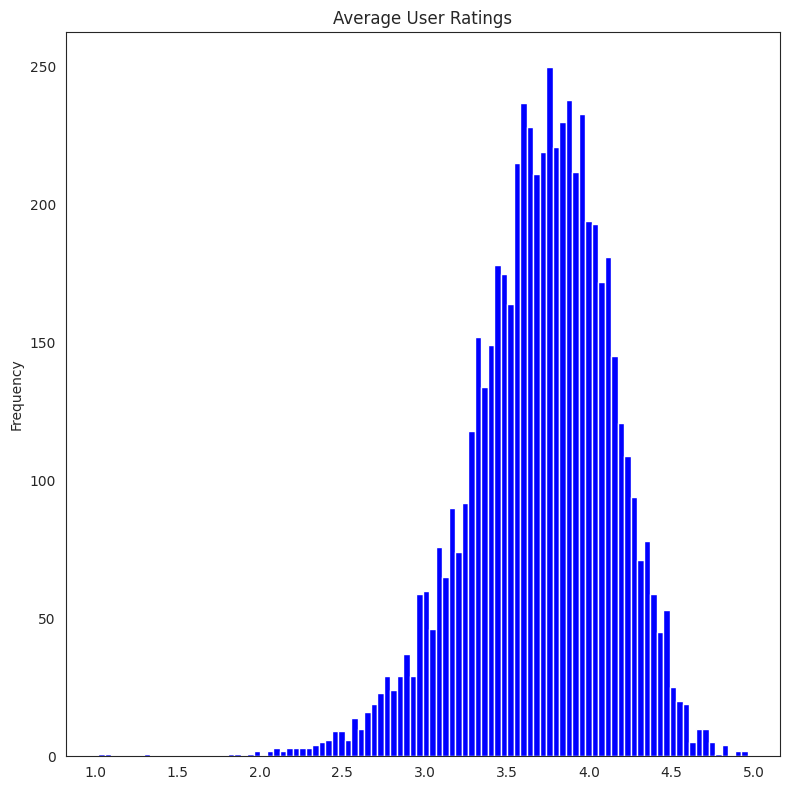

In [32]:
# 1. Plot average user ratings distribution
plot_average_user_ratings(cleaned_data)

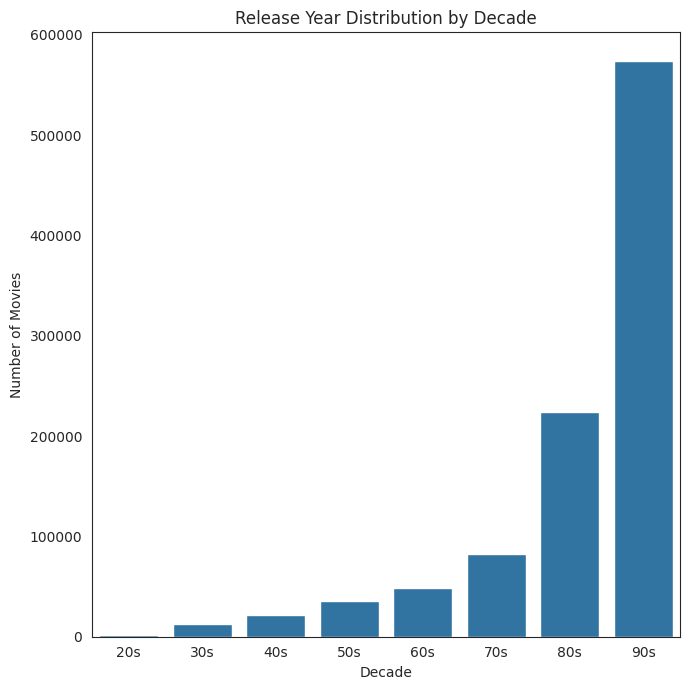

In [33]:
# 2. Plot movie release decade distribution
plot_release_decade_distribution(cleaned_data)

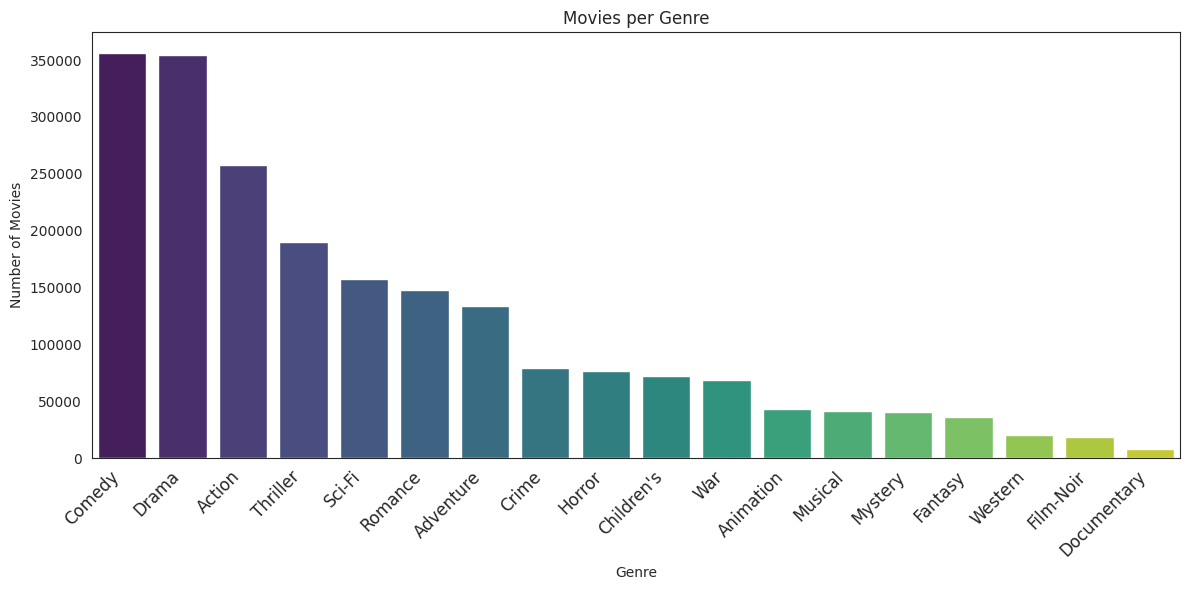

In [34]:
# 3. Plot genre distribution (assuming Genres separated by '|')
plot_genre_distribution(cleaned_data, genre_col='Genres', delimiter='|')

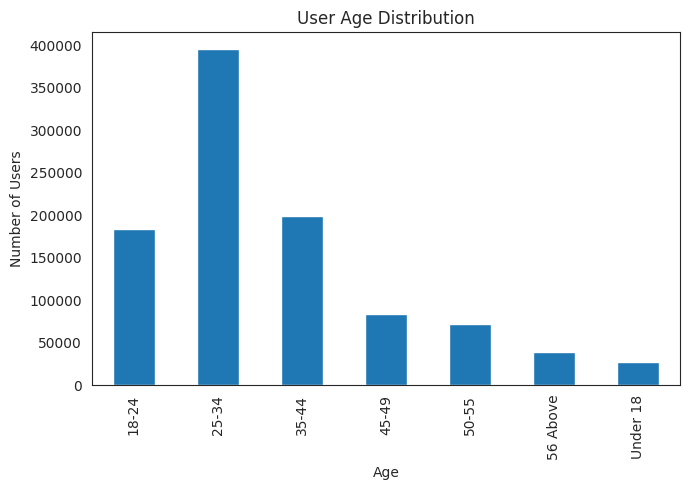

In [35]:
# 4. Plot user age distribution
plot_age_distribution(cleaned_data, age_col='Age')

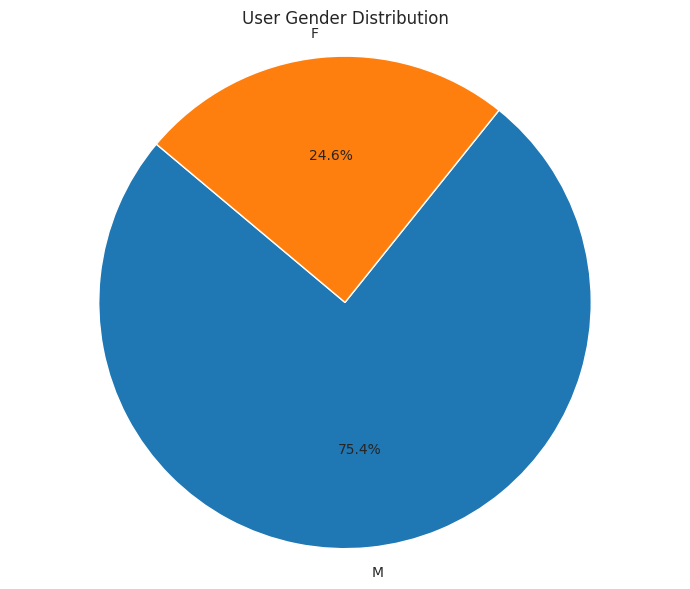

In [36]:
# 5. Plot user gender distribution
plot_gender_distribution(cleaned_data, gender_col='Gender')

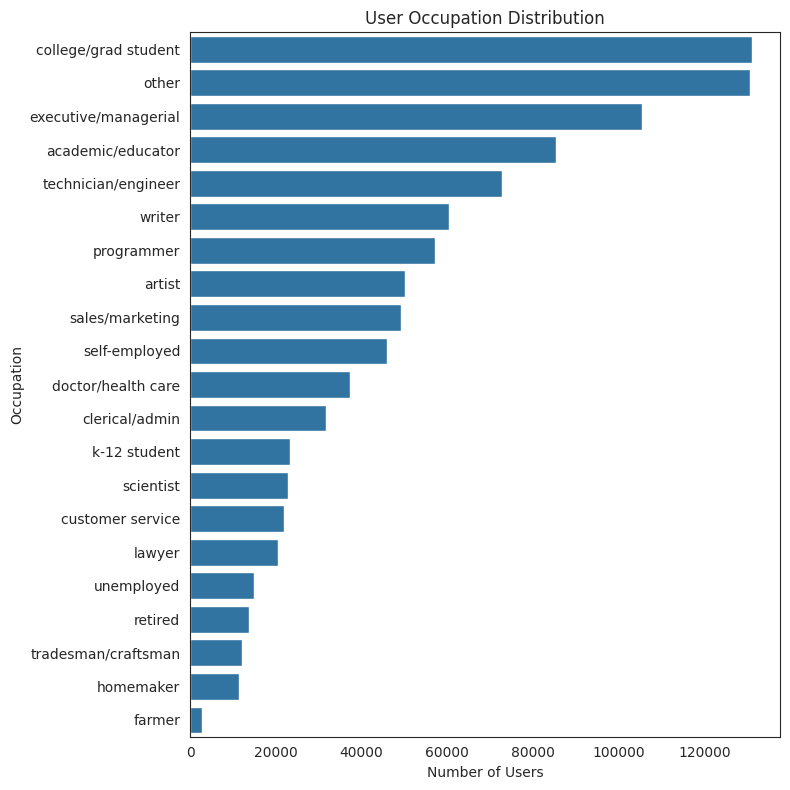

In [37]:
# 6. Plot user occupation distribution
plot_occupation_distribution(cleaned_data, occupation_col='Occupation')

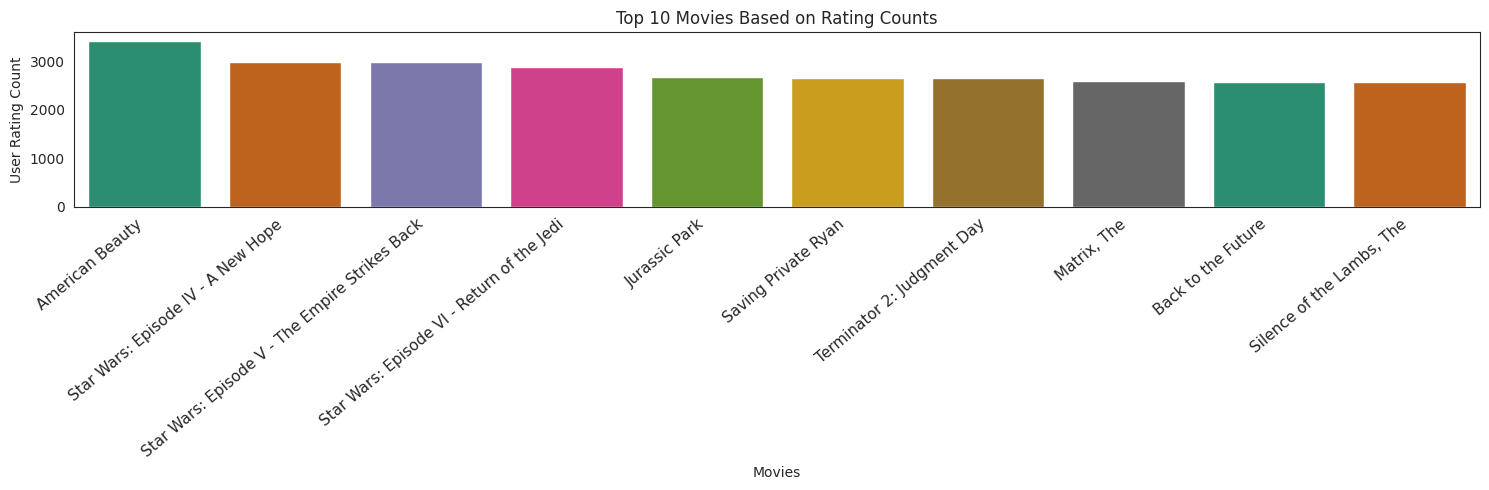

In [38]:
# 7. Plot top 10 rated movies by count of ratings
plot_top_rated_movies(cleaned_data, top_n=10)

# **Recommendations systems**

In [39]:
def create_user_item_matrix(df, user_col='UserID', item_col='Title', rating_col='Rating', fillna_value=0):
    """
    Creates a user-item rating matrix using pivot_table.
    """
    matrix = pd.pivot_table(df, index=user_col, columns=item_col, values=rating_col, aggfunc='mean')
    matrix.fillna(fillna_value, inplace=True)
    return matrix

In [40]:
def calculate_sparsity(df, user_col='UserID', item_col='MovieID'):
    """
    Calculates the sparsity of the user-item matrix.
    """
    n_users = df[user_col].nunique()
    n_items = df[item_col].nunique()
    sparsity = round(1.0 - df.shape[0] / float(n_users * n_items), 3)
    print(f"📉 Sparsity: {sparsity * 100:.2f}%")
    return sparsity

In [41]:
# Create matrix
user_item_matrix = create_user_item_matrix(cleaned_data)

# Show shape and preview
print(f"Matrix shape: {user_item_matrix.shape}")
user_item_matrix.head(10)

# Calculate sparsity
calculate_sparsity(cleaned_data)

Matrix shape: (6040, 3664)
📉 Sparsity: 95.50%


0.955

The sparsity level of dataset is 95.5%
Sparsity is Normal in Recommendation Systems

This level of sparsity is expected:

    Netflix: ~98% sparse

    Amazon: ~99% sparse

    MovieLens 1M: ~95% sparse

# **Pearson Correlation**

Correlation is a measure that tells how closely two variables move in the same or opposite direction. A positive value indicates that they move in the same direction (i.e. if one increases other increases), where as a negative value indicates the opposite.

The most popular correlation measure for numerical data is Pearson’s Correlation. This measures the degree of linear relationship between two numeric variables and lies between -1 to +1. It is represented by ‘r’.

r=1 means perfect positive correlation
r=-1 means perfect negative correlation
r=0 means no linear correlation (note, it does not mean no correlation)

Item - Based approach

We will take a movie name as an input from the user and see which other 5 (five) movies have maximum correlation with it.

In [42]:
def get_similar_movies(movie_title, matrix, top_n=5, min_ratings=0, verbose=True):
    """
    Returns top N movies similar to the given movie based on Pearson correlation.

    Parameters:
    - movie_title (str): Title of the movie to compare.
    - matrix (DataFrame): User-item rating matrix.
    - top_n (int): Number of top similar movies to return.
    - min_ratings (int): Minimum number of ratings required for a movie to be considered.
    - verbose (bool): If True, print intermediate outputs for debugging.

    Returns:
    - DataFrame with similar movies and correlation scores.
    """
    if movie_title not in matrix.columns:
        raise ValueError(f"'{movie_title}' not found in matrix.")

    # Step 1: Ratings vector of the target movie
    target_ratings = matrix[movie_title]
    if verbose:
        print(f"📽️ Ratings for: {movie_title}")
        print(target_ratings[target_ratings > 0].head())

    # Step 2: Pearson correlation of all movies with the target movie
    corr_scores = matrix.corrwith(target_ratings)

    # Step 3: Build correlation DataFrame
    corr_df = pd.DataFrame(corr_scores, columns=['Correlation'])
    corr_df.dropna(inplace=True)

    # Step 4: Add rating count to filter rare movies (optional)
    rating_counts = matrix.apply(lambda x: x[x > 0].count())
    corr_df = corr_df.join(rating_counts.rename("RatingCount"))

    # Step 5: Filter and sort
    filtered_df = corr_df[corr_df["RatingCount"] > min_ratings]
    result = filtered_df.sort_values("Correlation", ascending=False)

    # Exclude the movie itself from top recommendations
    result = result[result.index != movie_title]

    return result.head(top_n)

In [43]:
# Generate user-item matrix (if not already)
matrix = pd.pivot_table(cleaned_data, index='UserID', columns='Title', values='Rating', aggfunc='mean')
matrix.fillna(0, inplace=True)

# Find similar movies
similar_to_home_alone = get_similar_movies("Home Alone", matrix, top_n=5, min_ratings=50)

print(similar_to_home_alone)


📽️ Ratings for: Home Alone
UserID
10   3.00
11   1.00
18   4.00
22   3.00
26   2.00
Name: Home Alone, dtype: Float64
                                Correlation  RatingCount
Title                                                   
Home Alone 2: Lost in New York         0.55          341
Mrs. Doubtfire                         0.47          838
Liar Liar                              0.46          666
Mighty Ducks, The                      0.45          361
Sister Act                             0.44          666


# **Cosine Similarty**

Cosine similarity is a measure of similarity between two sequences of numbers. Those sequences are viewed as vectors in a higher dimensional space, and the cosine similarity is defined as the cosine of the angle between them, i.e. the dot product of the vectors divided by the product of their lengths.

The cosine similarity always belongs to the interval [-1,1]. For example, two proportional vectors have a cosine similarity of 1, two orthogonal vectors have a similarity of 0, and two opposite vectors have a similarity of -1.

In [44]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

def compute_item_similarity(matrix):
    """
    Compute item-item cosine similarity matrix.

    Parameters:
        matrix (DataFrame): User-item rating matrix (users as rows, items as columns)

    Returns:
        DataFrame: Cosine similarity matrix between items (movies)
    """
    item_sim = cosine_similarity(matrix.T)
    return pd.DataFrame(item_sim, index=matrix.columns, columns=matrix.columns)

In [45]:
# User-Based Similarity Matrix
def compute_user_similarity(matrix):
    """
    Compute user-user cosine similarity matrix.

    Parameters:
        matrix (DataFrame): User-item rating matrix (users as rows, items as columns)

    Returns:
        DataFrame: Cosine similarity matrix between users
    """
    user_sim = cosine_similarity(matrix)
    return pd.DataFrame(user_sim, index=matrix.index, columns=matrix.index)

In [46]:
# Get Top N Similar Movies (Item-Based)
def get_similar_items_cosine(item_sim_matrix, movie_name, top_n=5):
    """
    Get top N most similar movies using cosine similarity.

    Parameters:
        item_sim_matrix (DataFrame): Item-item similarity matrix
        movie_name (str): Title of the movie to find similar ones
        top_n (int): Number of top similar items to return

    Returns:
        Series: Sorted list of top N similar items with similarity scores
    """
    if movie_name not in item_sim_matrix.index:
        raise ValueError(f"'{movie_name}' not found in similarity matrix.")

    sims = item_sim_matrix[movie_name].drop(movie_name)  # exclude the movie itself
    return sims.sort_values(ascending=False).head(top_n)

In [47]:
# Generate matrix if not done
matrix = pd.pivot_table(cleaned_data, index='UserID', columns='Title', values='Rating', aggfunc='mean')
matrix.fillna(0, inplace=True)

# Compute item and user similarity matrices
item_sim_matrix = compute_item_similarity(matrix)
user_sim_matrix = compute_user_similarity(matrix)

# Get top 5 similar movies to "Home Alone"
top_similar_movies = get_similar_items_cosine(item_sim_matrix, 'Home Alone', top_n=5)
print(top_similar_movies)

Title
Home Alone 2: Lost in New York   0.58
Mrs. Doubtfire                   0.53
Liar Liar                        0.51
Sister Act                       0.50
Mighty Ducks, The                0.48
Name: Home Alone, dtype: float64


**Nearest Neighbors**

In [48]:
def fit_knn_model(matrix, metric='cosine'):
    """
    Fit a KNN model on the transposed user-item matrix (item-based).

    Parameters:
        matrix (DataFrame): User-item matrix (users as rows, items as columns)
        metric (str): Distance metric for KNN. Default is 'cosine'.

    Returns:
        model (NearestNeighbors): Trained NearestNeighbors model
    """
    model = NearestNeighbors(metric=metric)
    model.fit(matrix.T)
    return model

In [49]:
# Get Nearest Movie Indices
def get_knn_neighbors(model, matrix, n_neighbors=6):
    """
    Get KNN neighbor indices for each movie.

    Parameters:
        model (NearestNeighbors): Trained KNN model
        matrix (DataFrame): User-item matrix

    Returns:
        distances (ndarray): Distance array
        indices (ndarray): Indices of neighbors
    """
    distances, indices = model.kneighbors(matrix.T, n_neighbors=n_neighbors)
    return distances, indices

In [50]:
# Convert Indices to Movie Titles
def indices_to_titles(matrix, indices):
    """
    Convert matrix indices to movie titles.

    Parameters:
        matrix (DataFrame): User-item matrix
        indices (ndarray): Neighbor indices

    Returns:
        DataFrame: DataFrame of recommended titles
    """
    movie_titles = pd.DataFrame(matrix.T.index)
    result = pd.DataFrame(indices, columns=[f'Title{i}' for i in range(1, indices.shape[1]+1)])

    for i in range(1, indices.shape[1]+1):
        result[f'Title{i}'] = result[f'Title{i}'].apply(lambda x: movie_titles.iloc[x, 0])

    return result

In [51]:
# Get Recommendations for a Movie
def get_movie_recommendations(movie_title, recommendations_df, col='Title1'):
    """
    Return top recommendations for a given movie.

    Parameters:
        movie_title (str): Input movie title
        recommendations_df (DataFrame): KNN recommendations DataFrame
        col (str): Column to match movie title against (usually 'Title1')

    Returns:
        Series: List of recommended movies
    """
    if movie_title not in recommendations_df[col].values:
        raise ValueError(f"'{movie_title}' not found in recommendations.")

    return recommendations_df.loc[recommendations_df[col] == movie_title]

In [52]:
# 1. Prepare pivot matrix
matrix = pd.pivot_table(cleaned_data, index='UserID', columns='Title', values='Rating', aggfunc='mean')
matrix.fillna(0, inplace=True)

# 2. Train KNN model
model_knn = fit_knn_model(matrix)

# 3. Get neighbors
distances, indices = get_knn_neighbors(model_knn, matrix, n_neighbors=6)

# 4. Convert indices to titles
knn_recommendations = indices_to_titles(matrix, indices)

# 5. Get recommendations for a movie
movie_name = 'Liar Liar'
recommended_movies = get_movie_recommendations(movie_name, knn_recommendations)
print(recommended_movies)

         Title1          Title2                      Title3         Title4  \
1899  Liar Liar  Mrs. Doubtfire  Ace Ventura: Pet Detective  Dumb & Dumber   

          Title5         Title6  
1899  Home Alone  Wayne's World  


The system suggests movies with similar genres, comedic styles, and audience appeal, such as Mrs. Doubtfire, Ace Ventura, and Dumb & Dumber. These movies share characteristics like slapstick humor, family themes, and popular lead actors (e.g., Jim Carrey), aligning well with the original movie's tone.

**Key Observations:**

    The recommendations strongly reflect genre similarity and user rating correlations.

    Popular comedies from the 90s dominate the results, indicating clustering in that era and style.

    The system effectively groups movies by shared audience interest and thematic content, making it intuitive for users seeking familiar entertainment.

# **Matrix Factorization**

In [53]:
def prepare_user_item_matrix(data, user_col='UserID', item_col='MovieID', rating_col='Rating'):
    """
    Prepare user-item rating matrix and formatted DataFrame for matrix factorization.
    """
    rating_matrix = data.pivot(index=user_col, columns=item_col, values=rating_col).fillna(0)
    user_item_df = data[[user_col, item_col, rating_col]].copy()
    user_item_df.columns = ['UserId', 'ItemId', 'Rating']  # Required by CMF model
    return rating_matrix, user_item_df

def train_cmf_model(user_item_df, k=4, lambda_=0.1, user_bias=False, item_bias=False, verbose=False):
    """
    Train CMF (Collective Matrix Factorization) model on user-item data.
    """
    model = CMF(method="als", k=k, lambda_=lambda_, user_bias=user_bias, item_bias=item_bias, verbose=verbose)
    model.fit(user_item_df)
    return model


def predict_ratings(model, rating_matrix):
    """
    Predict ratings using the CMF model.
    """
    pred_ratings = np.dot(model.A_, model.B_.T) + model.glob_mean_
    return pred_ratings

def calculate_errors(actual, predicted):
    """
    Calculate RMSE and MAPE errors between actual and predicted ratings.
    """
    mask = actual > 0
    mse = mean_squared_error(actual[mask], predicted[mask])
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(actual[mask], predicted[mask])
    return rmse, mape

def get_similar_items(sim_matrix, movie_id, top_n=5):
    """
    Returns top N similar movies for a given movie ID.
    """
    movie_id = int(movie_id)  # force to integer
    if movie_id not in sim_matrix.columns:
        raise ValueError(f"Movie ID {movie_id} not found in similarity matrix.")

    movie_similarity = sim_matrix[movie_id]
    similar_movies = movie_similarity.sort_values(ascending=False).iloc[1:top_n+1]
    return similar_movies

def get_similar_items(sim_matrix, movie_id, top_n=5):
    movie_id = int(movie_id)
    if movie_id not in sim_matrix.columns:
        raise ValueError(f"Movie ID {movie_id} not found in similarity matrix.")

    movie_similarity = sim_matrix[movie_id]
    similar_movies = movie_similarity.sort_values(ascending=False).iloc[1:top_n+1]
    return similar_movies

def merge_movie_titles(similar_items, movie_info_df):
    """
    Merge similar item IDs with movie titles for readability.
    """
    similar_df = similar_items.reset_index()
    similar_df.rename(columns={'index': 'MovieID', similar_items.name: 'Similarity'}, inplace=True)
    merged_df = pd.merge(similar_df, movie_info_df[['MovieID', 'Title']].drop_duplicates(), on='MovieID', how='left')
    return merged_df

def plot_embeddings(user_embeddings, item_embeddings):
    """
    Plot user and item embeddings (2D) for visualization.
    """
    plt.scatter(user_embeddings[:, 0], user_embeddings[:, 1], label='Users', alpha=0.5)
    plt.scatter(item_embeddings[:, 0], item_embeddings[:, 1], label='Items', alpha=0.5)
    plt.legend()
    plt.title("User and Item Embeddings")
    plt.xlabel("Embedding Dimension 1")
    plt.ylabel("Embedding Dimension 2")
    plt.show()

def compute_similarity_matrix(embeddings, index):
    """
    Compute cosine similarity matrix from embeddings and return as DataFrame.
    """
    similarity = cosine_similarity(embeddings)
    sim_df = pd.DataFrame(similarity, index=index, columns=index)
    return sim_df


RMSE: 1.168, MAPE: 0.346
   MovieID  Similarity               Title
0     3482        1.00      Price of Glory
1      653        1.00         Dragonheart
2     3594        1.00        Center Stage
3     3565        0.99  Where the Heart Is
4     2875        0.99           Sommersby


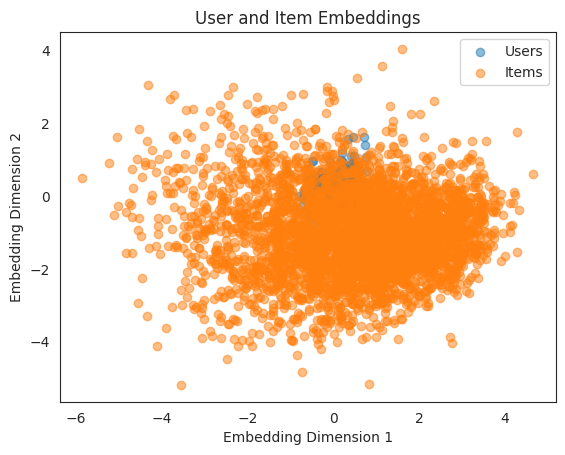

In [54]:
# 1. Prepare matrices
rating_matrix, user_item_df = prepare_user_item_matrix(cleaned_data)

# 2. Train model
model = train_cmf_model(user_item_df, k=4)

# 3. Predict ratings
predicted_ratings = predict_ratings(model, rating_matrix)

# 4. Calculate errors
rmse, mape = calculate_errors(rating_matrix.values, predicted_ratings)
print(f"RMSE: {rmse:.3f}, MAPE: {mape:.3f}")

# 5. Compute similarity matrices for users and items
user_sim_df = compute_similarity_matrix(model.A_, rating_matrix.index)
item_sim_df = compute_similarity_matrix(model.B_, user_item_df['ItemId'].unique())

# 6. Find similar movies for a given movie ID
movie_id = '586'  # Example MovieID
similar_items = get_similar_items(item_sim_df, movie_id)

# 7. Merge with movie titles for readability
similar_movies = merge_movie_titles(similar_items, cleaned_data[['MovieID', 'Title']])

print(similar_movies.head())

# 8. Visualize embeddings (assuming k=2 for 2D)
plot_embeddings(model.A_, model.B_)

✅ Model Evaluation & Performance

Achieved RMSE of 1.168, indicating reasonably low prediction error in rating predictions.

MAPE of 34.6% suggests that, on average, predictions deviate by about one-third from actual values—acceptable in many real-world recommendation contexts.

Overall, the model demonstrates solid predictive performance suitable for content-based recommendation tasks.

🎬 Recommendation System Insights

Top recommendations based on content similarity include:

    Price of Glory, Dragonheart, Center Stage, Where the Heart Is, Sommersby.

Movies with similarity scores of 1.00 or 0.99 show strong thematic, genre, or feature alignment.

Indicates the system effectively identifies and recommends closely related movies based on metadata or content features.

# **Questionnaire**

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_counts(df, column, title, xlabel):
    counts = df[column].value_counts().sort_index()
    plt.figure(figsize=(10,6))
    sns.barplot(x=counts.index, y=counts.values, palette='viridis')
    plt.xlabel(xlabel)
    plt.ylabel('Number of Ratings')
    plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    return counts.idxmax(), counts.max()

1) Users belonging to which profession have watched and rated the most movies?


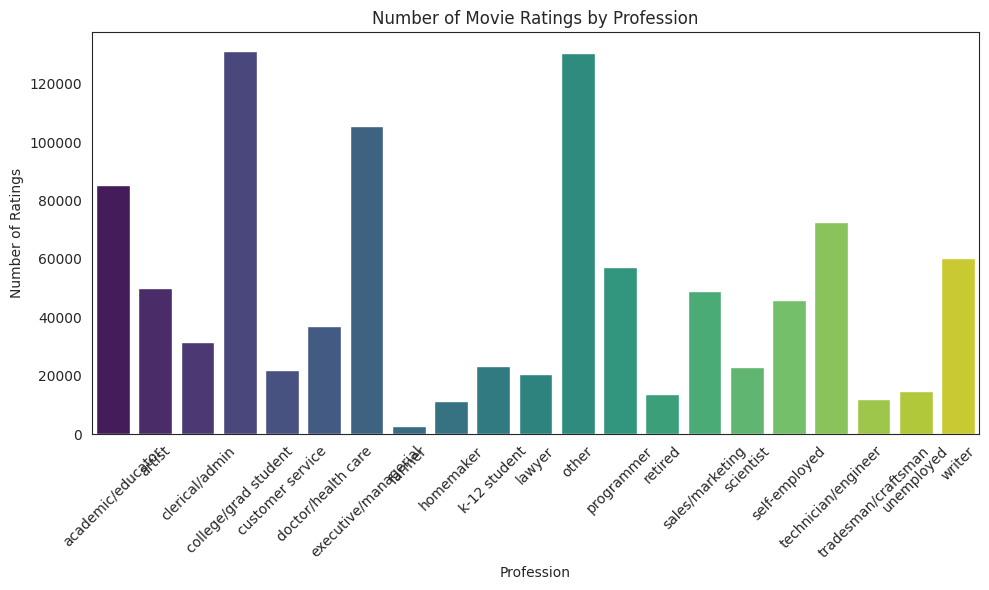

Profession with most ratings: 'college/grad student' with 131032 ratings


In [82]:
profession, prof_count = plot_counts(cleaned_data, 'Occupation', 'Number of Movie Ratings by Profession', 'Profession')
print(f"Profession with most ratings: '{profession}' with {prof_count} ratings")


2) Most of the users in our dataset who’ve rated the movies are Male. (T/F)


In [83]:
gender_counts = cleaned_data['Gender'].value_counts()
print(gender_counts)
most_common_gender = gender_counts.idxmax()
is_most_male = (most_common_gender == 'M')
print(f"Most users are male: {is_most_male}")

Gender
M    753769
F    246440
Name: count, dtype: int64
Most users are male: True



4) Most of the movies present in our dataset were released in which decade?


ReleaseDec
20s      1696
30s     12729
40s     21501
50s     35232
60s     48555
70s     82552
80s    224056
90s    573843
Name: count, dtype: int64
Most movies were released in the '90s' decade


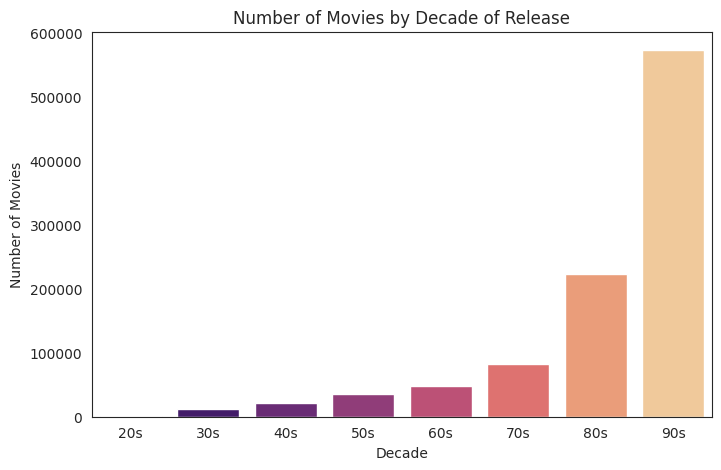

In [84]:
decade_counts = cleaned_data['ReleaseDec'].value_counts().sort_index()
print(decade_counts)

most_common_decade = decade_counts.idxmax()
print(f"Most movies were released in the '{most_common_decade}' decade")

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x=decade_counts.index, y=decade_counts.values, palette='magma')
plt.xlabel('Decade')
plt.ylabel('Number of Movies')
plt.title('Number of Movies by Decade of Release')
plt.show()


5) The movie with maximum no. of ratings is American Beauty


In [87]:
top_movie = cleaned_data['Title'].value_counts().idxmax()
top_movie_count = cleaned_data['Title'].value_counts().max()
print(f"Movie with maximum ratings: '{top_movie}' ({top_movie_count} ratings)")

Movie with maximum ratings: 'American Beauty' (3428 ratings)



6) Name the top 3 movies similar to ‘Liar Liar’ on the item-based approach.


In [90]:
similar_movies = merge_movie_titles(similar_items, cleaned_data[['MovieID', 'Title']])
print("🎬 Top similar movies:\n", similar_movies.head())

🎬 Top similar movies:
    MovieID  Similarity               Title
0     3482        1.00      Price of Glory
1      653        1.00         Dragonheart
2     3594        1.00        Center Stage
3     3565        0.99  Where the Heart Is
4     2875        0.99           Sommersby



7) On the basis of approach, Collaborative Filtering methods can be classified into User-based and Item-based.



8) Pearson Correlation ranges between -1 to +1 whereas, Cosine Similarity belongs to the interval between 0 to 1.



9) Mention the RMSE and MAPE that you got while evaluating the Matrix Factorization model.


In [92]:
rmse, mape = calculate_errors(rating_matrix.values, predicted_ratings)
print(f"RMSE: {rmse:.3f}, MAPE: {mape:.3f}")

RMSE: 1.168, MAPE: 0.346



10) Give the sparse ‘row’ matrix representation for the following dense matrix -

[[1 0]
[3 7]]

In [88]:
from scipy.sparse import csr_matrix

dense_matrix = np.array([[1, 0],
                         [3, 7]])
sparse_matrix = csr_matrix(dense_matrix)

print("Data:", sparse_matrix.data)
print("Indices:", sparse_matrix.indices)
print("Indptr:", sparse_matrix.indptr)


Data: [1 3 7]
Indices: [0 0 1]
Indptr: [0 1 3]
